# LaMem Preprocessing — ViT-L/14 Embeddings + EmotionCLIP-V2

## Category Alignment Strategy

EmotionCLIP-V2 uses **9 categories**: `amusement, anger, awe, contentment, disgust, excitement, fear, sadness, neutral`.

LaMem uses **5 categories**: `amusement, awe, contentment, excitement, sadness` — a strict subset.

This notebook saves **both** representations:
- `ec2_<emotion>`: full 9-dim softmax vector from EmotionCLIP-V2 (all categories)
- `ec2_lamem_<emotion>`: 5-dim vector re-normalized to the LaMem subset only
- `ec2_residual`: summed probability mass of the 4 extra categories (`anger + disgust + fear + neutral`)

This allows direct comparison with original LaMem labels while preserving the richer 9-class signal.

In [ ]:
!pip install -q git+https://github.com/openai/CLIP.git
!git clone -q https://huggingface.co/jiangchengchengNLP/EmotionCLIP-V2
!pip install -q sentence-transformers

  Preparing metadata (setup.py) ... done


In [ ]:
!ls -lh /content/EmotionCLIP-V2

total 291M
-rw-r--r-- 1 root root  51K Apr 27 21:56 'Dog sad.jpg'
-rw-r--r-- 1 root root 6.9K Apr 27 21:56  EmotionCLIP.py
drwxr-xr-x 4 root root 4.0K Apr 28 00:04  EmotionCLIP-V2
-rw-r--r-- 1 root root 291M Apr 27 21:56  EmotionCLIP-V2.pth
-rw-r--r-- 1 root root 1.1K Apr 27 21:56  preprocess.pkl
drwxr-xr-x 2 root root 4.0K Apr 27 21:56  __pycache__
-rw-r--r-- 1 root root 6.4K Apr 27 21:56  README.md
-rw-r--r-- 1 root root 8.7K Apr 27 21:56  Text_Encoder.py
-rw-r--r-- 1 root root   37 Apr 27 21:56  tokenize.pkl
-rw-r--r-- 1 root root  12K Apr 27 21:56  VIT.py


In [ ]:
!find /content/EmotionCLIP-V2 -name "*.pth"

/content/EmotionCLIP-V2/EmotionCLIP-V2/EmotionCLIP-V2.pth
/content/EmotionCLIP-V2/EmotionCLIP-V2.pth


In [ ]:
import json
import sys
import requests
import numpy as np
import pandas as pd
from PIL import Image
from io import BytesIO
from pathlib import Path
from tqdm import tqdm
import torch
import torch.nn.functional as F

import clip


import os
os.chdir("/content/EmotionCLIP-V2")

import sys
sys.path.insert(0, "/content/EmotionCLIP-V2")

from EmotionCLIP import model as ec2_model_fn, preprocess as ec2_preprocess_fn, tokenizer as ec2_tokenizer

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

情感识别： [[0. 0. 0. 0. 0. 0. 0. 1. 0.]]
预测的情感标签： sadness
泛化识别： [[0.2375 0.2568 0.2568 0.2489]]
预测的泛化标签： dog
Mounted at /content/drive


In [ ]:
ROOT_DIR       = "/content/drive/MyDrive/CompNeuroscience-P1"
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE     = 500
OUTPUT_DIR     = Path(ROOT_DIR) / "lamem_features_v2"
IMAGES_DIR     = Path(ROOT_DIR) / "lamem_images"
DATA_JSON      = Path(ROOT_DIR) / "data.json"
BASE_IMAGE_URL = "http://memorability.csail.mit.edu/imgs/"

# EmotionCLIP-V2 full label set
EC2_EMOTIONS = ["amusement", "anger", "awe", "contentment", "disgust", "excitement", "fear", "sadness", "neutral"]

# LaMem subset — strict intersection with EC2_EMOTIONS
LAMEM_EMOTIONS = ["amusement", "awe", "contentment", "excitement", "sadness"]
LAMEM_IDX      = [EC2_EMOTIONS.index(e) for e in LAMEM_EMOTIONS]  # indices into EC2 vector
EXTRA_IDX      = [i for i, e in enumerate(EC2_EMOTIONS) if e not in LAMEM_EMOTIONS]

OUTPUT_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")
print(f"EC2 emotion order:    {EC2_EMOTIONS}")
print(f"LaMem subset indices: {LAMEM_IDX} → {LAMEM_EMOTIONS}")
print(f"Extra indices:        {EXTRA_IDX} → {[EC2_EMOTIONS[i] for i in EXTRA_IDX]}")

Device: cuda
EC2 emotion order:    ['amusement', 'anger', 'awe', 'contentment', 'disgust', 'excitement', 'fear', 'sadness', 'neutral']
LaMem subset indices: [0, 2, 3, 5, 7] → ['amusement', 'awe', 'contentment', 'excitement', 'sadness']
Extra indices:        [1, 4, 6, 8] → ['anger', 'disgust', 'fear', 'neutral']


## Load Models

In [ ]:
# ViT-L/14 — image backbone for raw embeddings
clip_model, clip_preprocess = clip.load("ViT-L/14", device=DEVICE)
clip_model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)


In [ ]:
# EmotionCLIP-V2 — fine-tuned on EmoSet118K, 9 emotion categories
ec2_model      = ec2_model_fn.to(DEVICE)
ec2_preprocess = ec2_preprocess_fn
ec2_model.eval()

# Pre-encode all 9 emotion text prompts once
ec2_text_list   = [f"This picture conveys a sense of {e}" for e in EC2_EMOTIONS]
ec2_text_tokens = ec2_tokenizer(ec2_text_list).to(DEVICE)

with torch.no_grad():
    ec2_text_features = ec2_model.encode_text(ec2_text_tokens)
    ec2_text_features = ec2_text_features / ec2_text_features.norm(dim=-1, keepdim=True)

## Helper Functions

In [ ]:
def fetch_image(url: str, local_path: Path) -> Image.Image | None:
    if local_path.exists():
        return Image.open(local_path).convert("RGB")
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        local_path.parent.mkdir(parents=True, exist_ok=True)
        local_path.write_bytes(r.content)
        return Image.open(BytesIO(r.content)).convert("RGB")
    except Exception:
        return None


def get_vit_features(image: Image.Image) -> np.ndarray:
    tensor = clip_preprocess(image).unsqueeze(0).to(DEVICE)
    tensor = tensor.to(next(clip_model.parameters()).dtype)
    with torch.no_grad():
        feat = clip_model.encode_image(tensor)
        feat = feat / feat.norm(dim=-1, keepdim=True)
    return feat.cpu().float().numpy()[0]


def get_ec2_emotions(image: Image.Image) -> dict:
    tensor = ec2_preprocess(image).unsqueeze(0).to(DEVICE)
    tensor = tensor.to(next(ec2_model.parameters()).dtype)
    with torch.no_grad():
        img_feat = ec2_model.encode_image(tensor)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        logits = (img_feat @ ec2_text_features.T)
        scores9 = F.softmax(logits, dim=-1).cpu().float().numpy()[0]
    scores5_raw = scores9[LAMEM_IDX]
    scores5 = scores5_raw / scores5_raw.sum()
    residual = float(scores9[EXTRA_IDX].sum())
    ec2_label = EC2_EMOTIONS[int(scores9.argmax())]
    ec2_label_lamem = LAMEM_EMOTIONS[int(scores5.argmax())]
    return {
        "ec2_label": ec2_label,
        "ec2_label_lamem": ec2_label_lamem,
        "ec2_residual": residual,
        **{f"ec2_{e}": float(scores9[i]) for i, e in enumerate(EC2_EMOTIONS)},
        **{f"ec2_lamem_{e}": float(scores5[j]) for j, e in enumerate(LAMEM_EMOTIONS)},
    }


def save_batch(records: list[dict], vit_vecs: list[np.ndarray], batch_idx: int):
    df = pd.DataFrame(records)
    path = OUTPUT_DIR / f"batch_{batch_idx:04d}.parquet"
    df.to_parquet(path, index=False)
    npy_path = OUTPUT_DIR / f"batch_{batch_idx:04d}_vit.npy"
    np.save(npy_path, np.stack(vit_vecs))
    print(f"Saved {len(records)} records → {path.name} + {npy_path.name}")


## Main Processing Loop

In [ ]:
with open(DATA_JSON) as f:
    data = json.load(f)

done_files  = sorted(OUTPUT_DIR.glob("batch_*.parquet"))
done_count  = sum(len(pd.read_parquet(p)) for p in done_files)
batch_num   = len(done_files)
print(f"Total images: {len(data)} | Already processed: {done_count} | Resuming from index {done_count}")

Total images: 16815 | Already processed: 0 | Resuming from index 0


In [ ]:
def get_ec2_emotions(image: Image.Image) -> dict:
    tensor = ec2_preprocess(image).unsqueeze(0).to(DEVICE)

    dtype = next(ec2_model.parameters()).dtype
    tensor = tensor.to(device=DEVICE, dtype=dtype)

    with torch.no_grad():
        img_feat = ec2_model.encode_image(tensor)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

        logits = (img_feat @ ec2_text_features.T.to(img_feat.dtype))
        scores9 = F.softmax(logits, dim=-1).cpu().float().numpy()[0]

    scores5_raw = scores9[LAMEM_IDX]
    scores5 = scores5_raw / scores5_raw.sum()
    residual = float(scores9[EXTRA_IDX].sum())

    ec2_label = EC2_EMOTIONS[int(scores9.argmax())]
    ec2_label_lamem = LAMEM_EMOTIONS[int(scores5.argmax())]

    return {
        "ec2_label": ec2_label,
        "ec2_label_lamem": ec2_label_lamem,
        "ec2_residual": residual,
        **{f"ec2_{e}": float(scores9[i]) for i, e in enumerate(EC2_EMOTIONS)},
        **{f"ec2_lamem_{e}": float(scores5[j]) for j, e in enumerate(LAMEM_EMOTIONS)},
    }

In [ ]:
ec2_model.float() # Ensure model is in float32 for consistency

meta_buffer = []
vit_buffer = []

for item in tqdm(data[done_count:], initial=done_count, total=len(data)):
    local_path = IMAGES_DIR / item["name"]
    image = fetch_image(BASE_IMAGE_URL + item["name"], local_path)

    base = {
        "name": item["name"],
        "dataset": item.get("dataset", ""),
        "memscore": item.get("memscore", None),
        "original_emotion": item.get("emotion", ""),
    }

    # if image is None:
    #     meta_buffer.append({**base, "error": True})
    #     vit_buffer.append(np.zeros(768, dtype=np.float32))
    # else:
    #     try:
    vit_feat = get_vit_features(image)
    emotion_dict = get_ec2_emotions(image)
    meta_buffer.append({**base, "error": False, **emotion_dict})
    vit_buffer.append(vit_feat)
        # except Exception:
        #     meta_buffer.append({**base, "error": True})
        #     vit_buffer.append(np.zeros(768, dtype=np.float32))

    if len(meta_buffer) >= BATCH_SIZE:
        save_batch(meta_buffer, vit_buffer, batch_num)
        batch_num += 1
        meta_buffer = []
        vit_buffer = []

if meta_buffer:
    save_batch(meta_buffer, vit_buffer, batch_num)

  3%|▎         | 505/16815 [00:18<10:47, 25.17it/s]

Saved 500 records → batch_0000.parquet + batch_0000_vit.npy


  6%|▌         | 1003/16815 [00:37<10:16, 25.64it/s]

Saved 500 records → batch_0001.parquet + batch_0001_vit.npy


  9%|▉         | 1504/16815 [00:55<10:15, 24.87it/s]

...

Saved 500 records → batch_0031.parquet + batch_0031_vit.npy


 98%|█████████▊| 16504/16815 [10:06<00:11, 25.99it/s]

Saved 500 records → batch_0032.parquet + batch_0032_vit.npy


100%|██████████| 16815/16815 [10:18<00:00, 27.19it/s]


Saved 315 records → batch_0033.parquet + batch_0033_vit.npy


## Consolidate Outputs

In [ ]:
all_dfs  = [pd.read_parquet(p) for p in sorted(OUTPUT_DIR.glob("batch_*.parquet"))]
final_df = pd.concat(all_dfs, ignore_index=True)
final_df.to_parquet(OUTPUT_DIR / "lamem_features_v2_full.parquet", index=False)

vit_arrays = [np.load(p) for p in sorted(OUTPUT_DIR.glob("batch_*_vit.npy"))]
vit_matrix = np.concatenate(vit_arrays, axis=0)  # (N, 768)
np.save(OUTPUT_DIR / "vit_embeddings.npy", vit_matrix)

print(f"lamem_features_v2_full.parquet : {final_df.shape}")
print(f"vit_embeddings.npy             : {vit_matrix.shape}")
print(f"Images locally available       : {len(list(IMAGES_DIR.rglob('*.jpg')))}")
print(f"Original emotion labels        : {(final_df['original_emotion'] != '').sum()}")
print(f"Errors                         : {final_df['error'].sum()}")

lamem_features_v2_full.parquet : (16815, 22)
vit_embeddings.npy             : (16815, 768)
Images locally available       : 16815
Original emotion labels        : 540
Errors                         : 0


In [ ]:
final_df

,name,dataset,memscore,original_emotion,error,ec2_label,ec2_label_lamem,ec2_residual,ec2_amusement,ec2_anger,...,ec2_disgust,ec2_excitement,ec2_fear,ec2_sadness,ec2_neutral,ec2_lamem_amusement,ec2_lamem_awe,ec2_lamem_contentment,ec2_lamem_excitement,ec2_lamem_sadness
0,original/2.jpg,abnormal,0.694118,,False,neutral,contentment,0.446721,0.110778,0.111201,...,0.111079,0.109924,0.111114,0.109918,0.113327,0.200221,0.200895,0.201540,0.198678,0.198667
1,original/4.jpg,art,0.792208,amusement,False,amusement,amusement,0.442473,0.113314,0.111330,...,0.110008,0.112915,0.111349,0.109854,0.109787,0.203244,0.200622,0.196568,0.202528,0.197037
2,original/30.jpg,abnormal,0.848101,,False,anger,excitement,0.444703,0.111886,0.112307,...,0.110634,0.112088,0.111591,0.110211,0.110171,0.201489,0.201665,0.196521,0.201852,0.198473
3,original/53.jpg,art,0.764706,excitement,False,anger,excitement,0.445952,0.111464,0.112738,...,0.110097,0.111664,0.111202,0.110486,0.111915,0.201181,0.200454,0.197407,0.201541,0.199416
4,original/59.jpg,art,0.758242,awe,False,neutral,awe,0.446077,0.110501,0.110949,...,0.111456,0.110256,0.111321,0.110627,0.112350,0.199489,0.201164,0.200585,0.199047,0.199716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16810,original/48729.jpg,coco,0.772152,,False,neutral,awe,0.446885,0.111040,0.111795,...,0.110718,0.111265,0.111566,0.110538,0.112806,0.200754,0.201544,0.196696,0.201160,0.199846
16811,original/48730.jpg,coco,0.726190,,False,contentment,contentment,0.444114,0.111176,0.109449,...,0.111542,0.110915,0.111257,0.110210,0.111866,0.199998,0.200833,0.201381,0.199529,0.198259
16812,original/48731.jpg,coco,0.666667,,False,contentment,contentment,0.443667,0.111390,0.110747,...,0.110690,0.111511,0.110984,0.110414,0.111246,0.200222,0.199680,0.201192,0.200439,0.198467
16813,original/48732.jpg,coco,0.848101,,False,amusement,amusement,0.440726,0.113728,0.108883,...,0.110398,0.112160,0.110629,0.109428,0.110816,0.203350,0.199562,0.200881,0.200546,0.195661


In [ ]:
final_df.columns

Index(['name', 'dataset', 'memscore', 'original_emotion', 'error', 'ec2_label',
       'ec2_label_lamem', 'ec2_residual', 'ec2_amusement', 'ec2_anger',
       'ec2_awe', 'ec2_contentment', 'ec2_disgust', 'ec2_excitement',
       'ec2_fear', 'ec2_sadness', 'ec2_neutral', 'ec2_lamem_amusement',
       'ec2_lamem_awe', 'ec2_lamem_contentment', 'ec2_lamem_excitement',
       'ec2_lamem_sadness'],
      dtype='object')

In [ ]:
final_df.ec2_label.unique()

array(['neutral', 'amusement', 'anger', 'fear', 'excitement', 'sadness',
       'contentment', 'disgust', 'awe'], dtype=object)

In [ ]:
emo_df = final_df[final_df.original_emotion != ''].copy()
emo_df['original_emotion'] = emo_df['original_emotion'].replace('sad', 'sadness')
len(emo_df)

540

In [ ]:
EMOTIONS = emo_df.original_emotion.unique()
EMOTIONS

array(['amusement', 'excitement', 'awe', 'contentment', 'sadness'],
      dtype=object)

In [ ]:

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
y_true = emo_df["original_emotion"].str.lower().str.strip()
y_pred = emo_df["ec2_label"].str.lower().str.strip()

common_labels = sorted(set(y_true.unique()) & set(EMOTIONS))

print(f"Images with ground truth emotion: {len(emo_df)}")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, labels=common_labels))



Images with ground truth emotion: 540
Accuracy: 0.1037

              precision    recall  f1-score   support

   amusement       0.42      0.23      0.30       100
         awe       0.50      0.03      0.06       102
 contentment       0.21      0.09      0.13        67
  excitement       0.50      0.07      0.12       105
     sadness       0.74      0.10      0.18       166

   micro avg       0.44      0.10      0.17       540
   macro avg       0.47      0.10      0.16       540
weighted avg       0.52      0.10      0.16       540



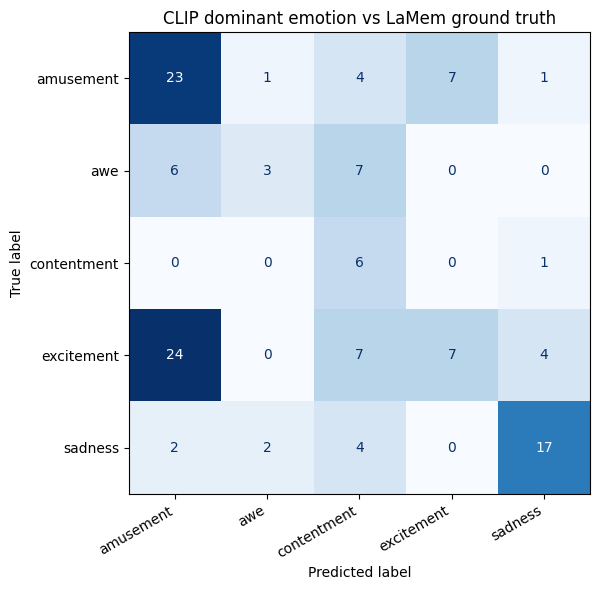

/tmp/ipykernel_45840/4077348419.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right")
/tmp/ipykernel_45840/4077348419.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right")


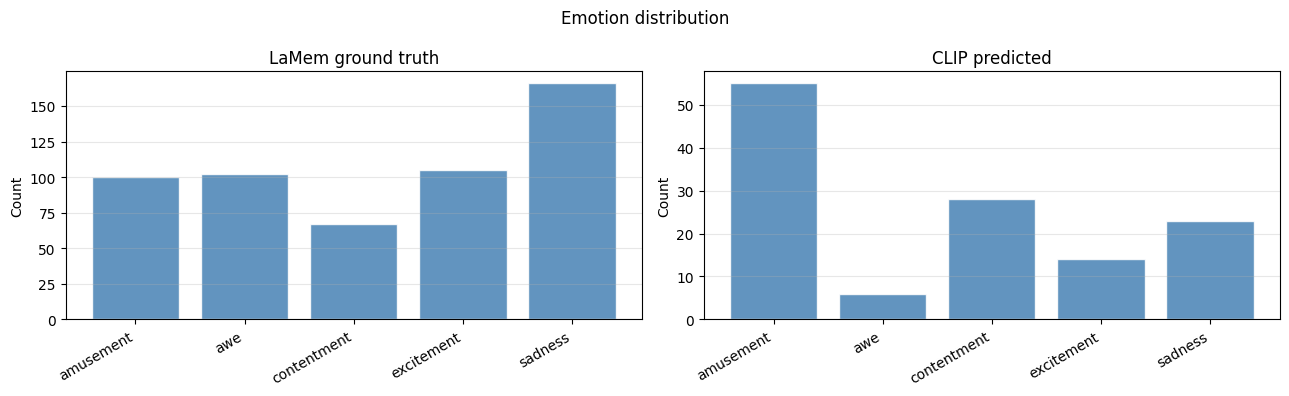

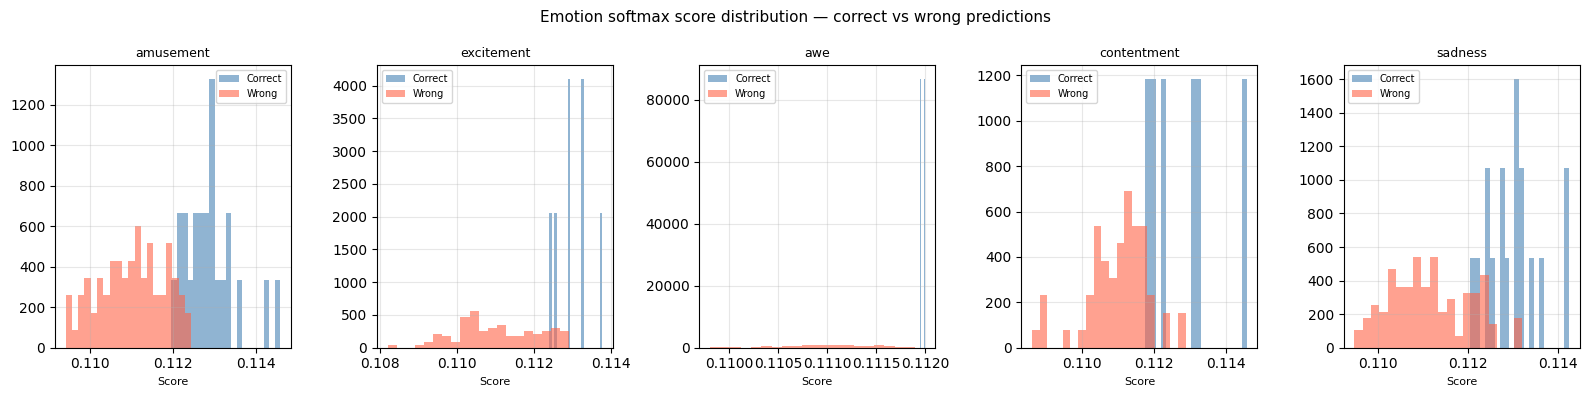

Memscore by prediction correctness:
         count    mean     std     min     25%     50%     75%     max
correct                                                               
False    484.0  0.7344  0.1290  0.3671  0.6417  0.7621  0.8313  0.9740
True      56.0  0.7975  0.1036  0.4568  0.7556  0.8199  0.8694  0.9512


/tmp/ipykernel_45840/4077348419.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(emotions_sorted, rotation=30, ha="right")


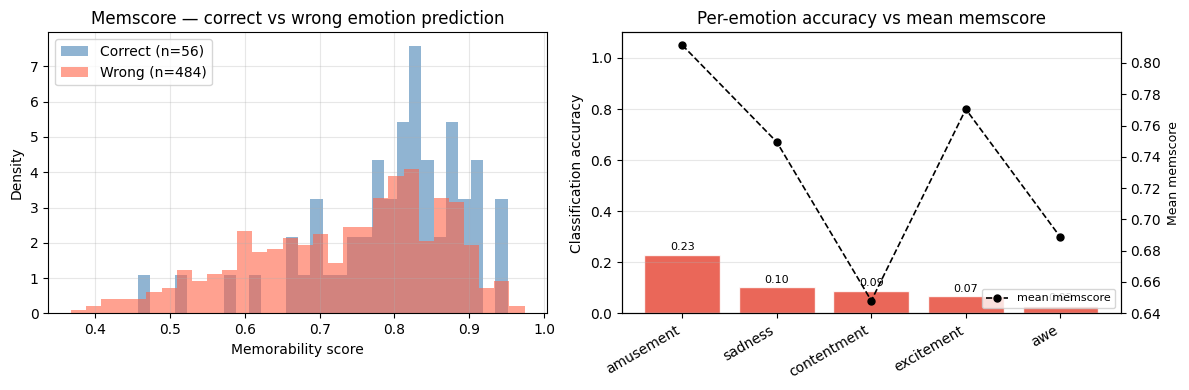

Top confusions (predicted | true | count):
  amusement      most confused with excitement     (n=7)
  awe            most confused with contentment    (n=7)
  contentment    most confused with sadness        (n=1)
  excitement     most confused with amusement      (n=24)
  sadness        most confused with contentment    (n=4)


In [47]:

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_true, y_pred, labels=common_labels)
ConfusionMatrixDisplay(cm, display_labels=common_labels).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("CLIP dominant emotion vs LaMem ground truth")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
# plt.savefig(f"{SAVE_DIR}/emotion_confusion_matrix.png", dpi=150)
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (col, title) in zip(axes, [
    ("original_emotion", "LaMem ground truth"),
    ("ec2_label", "CLIP predicted"),
]):
    counts = emo_df[col].str.lower().str.strip().value_counts().reindex(common_labels, fill_value=0)
    ax.bar(counts.index, counts.values, color="steelblue", alpha=0.85, edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.set_xticklabels(counts.index, rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Emotion distribution", fontsize=12)
plt.tight_layout()
# plt.savefig(f"{SAVE_DIR}/emotion_distribution.png", dpi=150)
plt.show()


score_cols = [f"ec2_{e}" for e in EMOTIONS]
fig, axes = plt.subplots(1, len(EMOTIONS), figsize=(16, 4), sharey=False)
for ax, e in zip(axes, EMOTIONS):
    col = f"ec2_{e}"
    for match, label, color in [(True, "Correct", "steelblue"), (False, "Wrong", "tomato")]:
        subset = emo_df[emo_df["original_emotion"].str.lower().str.strip() == e]
        matched = subset[subset["ec2_label"].str.lower().str.strip() == e]
        missed  = subset[subset["ec2_label"].str.lower().str.strip() != e]
        group   = matched if match else missed
        if len(group):
            ax.hist(group[col], bins=20, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(e, fontsize=9)
    ax.set_xlabel("Score", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
plt.suptitle("Emotion softmax score distribution — correct vs wrong predictions", fontsize=11)
plt.tight_layout()
# plt.savefig(f"{SAVE_DIR}/emotion_score_distributions.png", dpi=150)
plt.show()


emo_df["correct"] = (y_true == y_pred)
emo_df["error_abs"] = (emo_df["memscore"] - emo_df["memscore"].mean()).abs()

print("Memscore by prediction correctness:")
print(emo_df.groupby("correct")["memscore"].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for correct, label, color in [(True, "Correct", "steelblue"), (False, "Wrong", "tomato")]:
    subset = emo_df[emo_df["correct"] == correct]
    axes[0].hist(subset["memscore"], bins=30, alpha=0.6, label=f"{label} (n={len(subset)})",
                 color=color, density=True)
axes[0].set_xlabel("Memorability score")
axes[0].set_ylabel("Density")
axes[0].set_title("Memscore — correct vs wrong emotion prediction")
axes[0].legend()
axes[0].grid(alpha=0.3)

per_emotion = []
for e in common_labels:
    subset = emo_df[emo_df["original_emotion"].str.lower().str.strip() == e]
    acc    = (subset["ec2_label"].str.lower().str.strip() == e).mean()
    per_emotion.append((e, acc, subset["memscore"].mean()))

emotions_sorted, accs, mean_mem = zip(*sorted(per_emotion, key=lambda x: -x[1]))
colors = ["#2ecc71" if a >= 0.5 else "#e74c3c" for a in accs]
bars = axes[1].bar(emotions_sorted, accs, color=colors, edgecolor="white", alpha=0.85)
ax2 = axes[1].twinx()
ax2.plot(emotions_sorted, mean_mem, "o--", color="black", linewidth=1.2, markersize=5, label="mean memscore")
ax2.set_ylabel("Mean memscore", fontsize=9)
ax2.legend(loc="lower right", fontsize=8)
for bar, val in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=8)
axes[1].set_ylabel("Classification accuracy")
axes[1].set_title("Per-emotion accuracy vs mean memscore")
axes[1].set_xticklabels(emotions_sorted, rotation=30, ha="right")
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
# plt.savefig(f"{SAVE_DIR}/emotion_memscore_analysis.png", dpi=150)
plt.show()


conf_matrix_df = pd.DataFrame(cm, index=common_labels, columns=common_labels)
print("Top confusions (predicted | true | count):")
for true_e in common_labels:
    row = conf_matrix_df.loc[true_e].drop(true_e).sort_values(ascending=False)
    top = row.iloc[0]
    print(f"  {true_e:<14} most confused with {row.index[0]:<14} (n={int(top)})")


## Quick Sanity Check

Verify that:
- The 9-dim EC2 vectors sum to ~1
- The 5-dim LaMem-renorm vectors sum to ~1
- `ec2_residual` + sum of lamem-renorm * (1 - residual) ≈ 1 (i.e. residual is consistent)

In [48]:
ok = final_df[~final_df["error"]].head(100)

ec2_sum   = ok[[f"ec2_{e}" for e in EC2_EMOTIONS]].sum(axis=1)
lm_sum    = ok[[f"ec2_lamem_{e}" for e in LAMEM_EMOTIONS]].sum(axis=1)

assert (ec2_sum - 1.0).abs().max() < 1e-4, "EC2 softmax does not sum to 1"
assert (lm_sum  - 1.0).abs().max() < 1e-4, "LaMem renorm does not sum to 1"

print("Softmax checks passed.")
print(f"Mean ec2_residual: {ok['ec2_residual'].mean():.4f}  (probability mass outside LaMem categories)")

# Distribution of dominant emotions in the full 9-class space
print("\nec2_label distribution (full 9-class):")
print(final_df["ec2_label"].value_counts())

print("\nec2_label_lamem distribution (LaMem 5-class renorm):")
print(final_df["ec2_label_lamem"].value_counts())

if (final_df["original_emotion"] != "").any():
    match = (final_df["original_emotion"] == final_df["ec2_label_lamem"]).mean()
    print(f"\nLabel agreement (original_emotion vs ec2_label_lamem): {match:.3f}")

Softmax checks passed.
Mean ec2_residual: 0.4460  (probability mass outside LaMem categories)

ec2_label distribution (full 9-class):
ec2_label
neutral        10206
excitement      1675
amusement       1558
anger           1209
contentment      828
awe              429
sadness          362
disgust          291
fear             257
Name: count, dtype: int64

ec2_label_lamem distribution (LaMem 5-class renorm):
ec2_label_lamem
contentment    5551
awe            4841
amusement      2461
excitement     2378
sadness        1584
Name: count, dtype: int64

Label agreement (original_emotion vs ec2_label_lamem): 0.008


## Final Schema Summary

| Column | Description |
|---|---|
| `name`, `dataset`, `memscore`, `original_emotion` | Original LaMem metadata |
| `ec2_label` | Dominant emotion — argmax over all 9 EC2 categories |
| `ec2_label_lamem` | Dominant emotion — argmax over 5-dim renorm LaMem subset |
| `ec2_residual` | Total softmax mass in `anger + disgust + fear + neutral` |
| `ec2_<emotion>` × 9 | Full EmotionCLIP-V2 softmax vector |
| `ec2_lamem_<emotion>` × 5 | Renormalized 5-class vector (comparable to LaMem labels) |
| `error` | True if image could not be fetched |
| **`vit_embeddings.npy`** | ViT-L/14 image embeddings — shape `(N, 768)` |

In [49]:
from google.colab import runtime
runtime.unassign()